# LESSON 2.2 - DATA PREPARATION
## 2.2.1. import packages

In [2]:
import numpy  as np
import pandas as pd

## 2.2.2 - GET DATA

# Pass URL to dataset to the !wget function
data = 'https://github.com/alexeygrigorev/mlbookcamp-code/blob/master/chapter-02-car-price/data.csv'
!wget $data

pd.read_csv("data.csv")

In [3]:
url = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv"

df = pd.read_csv(url)
df.head()


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## 2.2.3 - PREPARING DATA

In [4]:
# show all column names
df.columns

#standardize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

# confirm standardized column names
df.head

<bound method NDFrame.head of           make       model  year                engine_fuel_type  engine_hp  \
0          BMW  1 Series M  2011     premium unleaded (required)      335.0   
1          BMW    1 Series  2011     premium unleaded (required)      300.0   
2          BMW    1 Series  2011     premium unleaded (required)      300.0   
3          BMW    1 Series  2011     premium unleaded (required)      230.0   
4          BMW    1 Series  2011     premium unleaded (required)      230.0   
...        ...         ...   ...                             ...        ...   
11909    Acura         ZDX  2012     premium unleaded (required)      300.0   
11910    Acura         ZDX  2012     premium unleaded (required)      300.0   
11911    Acura         ZDX  2012     premium unleaded (required)      300.0   
11912    Acura         ZDX  2013  premium unleaded (recommended)      300.0   
11913  Lincoln      Zephyr  2006                regular unleaded      221.0   

       engine_cylinde

In [5]:
# determine datatypes of all columns (dtypes attribute)
df.dtypes

# get all columns containing 'str' values
df.dtypes == 'str'

# create a dataframe containing only string columns
df.dtypes[df.dtypes == 'str']

# find index of all string columns
df.dtypes[df.dtypes == 'str'].index

# create a python list containing all the string column names
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

# standardize the string values in every string element of the dataframe
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

# review standardized data in dataframe 'df'
df.head()


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


# LESSON 2.3 - EXPLORATORY DATA ANALYSIS

In [6]:
# Review first values in every column
for col in df.columns:
    print(col)
    print(df[col].head())
    print()
    

make
0    bmw
1    bmw
2    bmw
3    bmw
4    bmw
Name: make, dtype: str

model
0    1_series_m
1      1_series
2      1_series
3      1_series
4      1_series
Name: model, dtype: str

year
0    2011
1    2011
2    2011
3    2011
4    2011
Name: year, dtype: int64

engine_fuel_type
0    premium_unleaded_(required)
1    premium_unleaded_(required)
2    premium_unleaded_(required)
3    premium_unleaded_(required)
4    premium_unleaded_(required)
Name: engine_fuel_type, dtype: str

engine_hp
0    335.0
1    300.0
2    300.0
3    230.0
4    230.0
Name: engine_hp, dtype: float64

engine_cylinders
0    6.0
1    6.0
2    6.0
3    6.0
4    6.0
Name: engine_cylinders, dtype: float64

transmission_type
0    manual
1    manual
2    manual
3    manual
4    manual
Name: transmission_type, dtype: str

driven_wheels
0    rear_wheel_drive
1    rear_wheel_drive
2    rear_wheel_drive
3    rear_wheel_drive
4    rear_wheel_drive
Name: driven_wheels, dtype: str

number_of_doors
0    2.0
1    2.0
2    2.0
3

In [7]:
# Review all unique values within each column
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

make
<StringArray>
[          'bmw',          'audi',          'fiat', 'mercedes-benz',
      'chrysler',        'nissan',         'volvo',         'mazda',
    'mitsubishi',       'ferrari',    'alfa_romeo',        'toyota',
       'mclaren',       'maybach',       'pontiac',       'porsche',
          'saab',           'gmc',       'hyundai',      'plymouth',
         'honda',    'oldsmobile',        'suzuki',          'ford',
      'cadillac',           'kia',       'bentley',     'chevrolet',
         'dodge',   'lamborghini',       'lincoln',        'subaru',
    'volkswagen',        'spyker',         'buick',         'acura',
   'rolls-royce',      'maserati',         'lexus',  'aston_martin',
    'land_rover',         'lotus',      'infiniti',         'scion',
       'genesis',        'hummer',         'tesla',       'bugatti']
Length: 48, dtype: str

model
<StringArray>
[  '1_series_m',     '1_series',          '100',   '124_spider',
    '190-class',     '2_series',          '2

In [8]:
# Review first five unique values within each column
# count the total number of unique values in column
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

# DATA VISUALIZATION

In [9]:
# Import packages
import matplotlib.pyplot as plt
import seaborn as sns

# configure notebook so that you can see the visualizations in the notebook
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

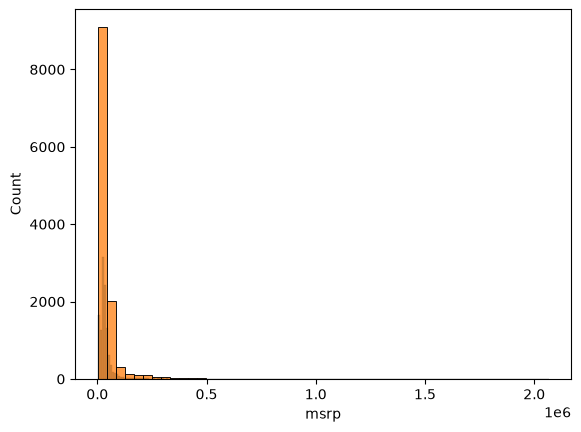

In [10]:
# histogram of prices (MSRP)
sns.histplot(df.msrp)

# graph is hard to read, so tell matplotlib to use a smaller amount of bins

sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

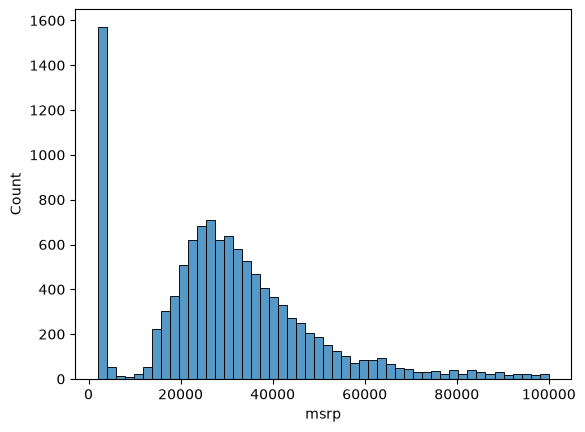

In [11]:
# Graph interpretation notes
#   x-axis range is from zero to 1e6 (1e6 = 1,000,000)
#   graph displays a 'long-tail' distribution

# Most data is below 100,000 
#   regenerate histogram after dropping outliers
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [12]:
#############################################################
# LEARNING TIME
#############################################################
# # Long-Tail distributions confuse models
#  1. To get rid of a long tail, we usually apply a logarythmic distribution
#  2. applying a logarythm to the price will give you more compact values
#       np.log([1, 1, 10, 1000, 100000])
#       returns: array(0.          0.          2.30258509  6.90775528 11.51292546)

# working with logarythm basics
#  1. you cannot calculate the log of zero because it would reqire dividing by zero
#       np.log([0, 1, 10, 1000, 100000])
#       returns: stack dump
#  2. workaround is to add one to every value 
#       np.log([0+1, 1+1, 10+1, 1000+1, 100000+1])
#       returns: array([ 0.          0.69314718  2.39789527  6.90875478 11.51293546])
#       compare: array([ 0.          0.          2.30258509  6.90775528 11.51292546)
#  3. Shortcut method for adding 1 to each value passed to the log() function
#     'log1p' gets its name from log plus one
#       np.log1p([0, 1, 10, 1000, 100000])
#       returns: array([ 0.          0.69314718  2.39789527  6.90875478 11.51293546])


<Axes: xlabel='msrp', ylabel='Count'>

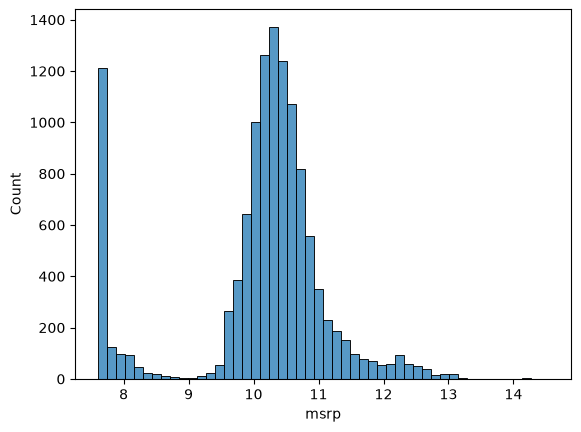

In [13]:
# 1. Convert prices into log representations of prices
price_logs = np.log1p(df.msrp)

# 2. histogram
sns.histplot(price_logs, bins=50)

### INTERPRETATION

histogram now resembles a normal distribution (when you ignore the bottom values)

In [14]:
# Check for missing values
# NOTE: we will have to do someting about the missing values before we can train a model
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# LESSON 2.4 - SETTING UP THE VALIDATION FRAMEWORK

In [105]:
# We need to split the dataset into 3 pieces:
#  1. Training      60%
#  2. Validation    20%
#  3. Testing       20%
# (split percentages can vary)

# Each piece needs to be split
#  1. feature matrix
#  2. target / label matrix (vector)

# Estimate the size of each new dataset
#  len() function counts the number of elements
#  int() rounds fractional values to the nearest integer
print("-1.--estimate ideal piece sizes---")
print(f"df size:            {int(len(df))}")
print(f"train df size:      {int(len(df)*.6)}")
print(f"validation df size: {int(len(df)*.2)}")
print(f"test df size:       {int(len(df)*.2)}")
print("---------------------------------------")
print(f"sum of parts size:  {(int(len(df)*.6) + int(len(df)*.2) + int(len(df)*.2))}")

# we rounded, the size of df != sum of df piece sizes
# to fix, we need to use subtraction
n       = len(df)
n_val   = int(len(df)*.2)
n_test  = int(len(df)*.2)
n_train = len(df) - n_val - n_test

print()
print("-2.--corrected estimate ideal piece sizes---")
print(f"df size:            {n}")
print(f"train df size:      {n_train}")
print(f"validation df size: {n_val}")
print(f"test df size:       {n_test}")
print("---------------------------------------")
print(f"sum of parts size:  {(n_train + n_val + n_test)}")

############################################################
# REVIEW: To extract rows from a dataframe,
#  1. Extract them by index 
#     - you can use a list of row numbers 
#     - using .iloc() tells python to use the default system index values
#                     this protects your code from renamed index values
#       df.iloc[0,1,2,3,4,5,6,7,8,9]
#       df.iloc[:10]  # start: tells python to start at the beginning 
#                        # end:   continue until getting to the 10th element
print()
# all of these are equivalent ways to select the top 10 rows of np
# df.iloc[[0,1,2,3,4,5,6,7,8,9]] # hardcoded list
# df.iloc[np.arange(0, 10)]      # numpy range function returns a list
# df.iloc[0:10]                  # [0:10] list notation
# df.iloc[list(range(10))]       # native python range() and list() functinos
# df.iloc[:10]                   # [:10] is list notation for the first 10 rows
# df.iloc[10:]                   # [10:] is list notation from the 10th row to the end
print("-3.--------------------------------------")
print(f"first 10 rows:\r\n{df.iloc[:10]}")
print("---------------------------------------")

print()
print("-4.--------------------------------------")
print("split dataframe into ml dataframe pieces")
print("---------------------------------------")
df_train = df.iloc[:n_train]
df_val   = df.iloc[n_train:n_train + n_val]
df_test  = df.iloc[n_train + n_val:]


# issue: raw data was sorted by make
#        this means that different ml datasets will not represent all makes
# solution: shuffle or randomize the data before creating ml datasets
idx = np.arange(n)      # create a new vector that can be used to replace the  
                        #   original df index
print()
print("-5.--------------------------------------")
print(f"first 10 idx rows:\r\n{idx[:10]}")

np.random.seed(2)       # set the seed for the random number generator
                        #   this makes the result sets reproducable
np.random.shuffle(idx)  # shuffle the values in this vector
                        #   NOTE: function shuffles the values in-place and 
                        #     returns void
print()
print("-6.--------------------------------------")
print(f"first 10 shuffled idx rows:\r\n{idx[:10]}")
print()
print("-7.--------------------------------------")
print(f"first 5 unshuffled df rows:\r\n{df[:5]}")
print()
print("-8.--------------------------------------")
print(f"first 5 shuffled idx rows: \r\n{df.iloc[idx[:5]]}")
# randomize rows (a/k/a shuffle)
df_train = df.iloc[idx[:n_train]]
df_val   = df.iloc[idx[n_train:n_train + n_val]]
df_test  = df.iloc[idx[n_train + n_val:]]

# preview ml dataset
print()
print("-9.--------------------------------------")
print(f"first 5 df_train rows: \r\n{df_train.iloc[:5]}")

# check length of ml datasets
print("-10.--------------------------------------")
print("lengths: df_train, df_val, df_test")
len(df_train), len(df_val), len(df_test)

# we don't need the original df index values in the ml dataframes
# create new dataframs with a sequential index
#   drop=True  means that the original index will be discarded
#   drop=False would have preserved the original index and added a new one
#     NOTE: True and False must start with a capital letter
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)
print()
print("-11.--------------------------------------")
print("reset_index: df_train, df_val, df_test")

# Create label dataframes for each of these ml dataframes
#   Remember that we are trying to predict the log of MSRP, not MSRP
# preview the values before creating the label dataframes
np.log1p(df_train.msrp.values)

# create the label dataframes
y_train = np.log1p(df_train.msrp.values)
y_val   = np.log1p(df_val.msrp.values)
y_test  = np.log1p(df_test.msrp.values)

print()
print("-12.--------------------------------------")
print("label dataframes created")

# Now we need to drop the MSRP columns from the ml feature dataframes
#  to prevent the model from seeing the label as a feature
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']
print()
print("-13.--------------------------------------")
print("'msrp' columns dropped from feature dataframes")

print()
print("-14.--------------------------------------")
print("confirm dataframe lengths")
print("lengths: df_train, df_val, df_test")
print(len(df_train), len(df_val), len(df_test))
print()
print("lengths: y_train, y_val, y_test")
print(len(y_train), len(y_val), len(y_test))

-1.--estimate ideal piece sizes---
df size:            11914
train df size:      7148
validation df size: 2382
test df size:       2382
---------------------------------------
sum of parts size:  11912

-2.--corrected estimate ideal piece sizes---
df size:            11914
train df size:      7150
validation df size: 2382
test df size:       2382
---------------------------------------
sum of parts size:  11914

-3.--------------------------------------
first 10 rows:
  make       model  year             engine_fuel_type  engine_hp  \
0  bmw  1_series_m  2011  premium_unleaded_(required)      335.0   
1  bmw    1_series  2011  premium_unleaded_(required)      300.0   
2  bmw    1_series  2011  premium_unleaded_(required)      300.0   
3  bmw    1_series  2011  premium_unleaded_(required)      230.0   
4  bmw    1_series  2011  premium_unleaded_(required)      230.0   
5  bmw    1_series  2012  premium_unleaded_(required)      230.0   
6  bmw    1_series  2012  premium_unleaded_(require

In [101]:
y_train = np.log1p(df_train.msrp.values)

# LESSON 2.5 - LINEAR REGRESSION

# LESSON 2.6 - LINEAR REGRESSION: VECTOR FORM

# LESSON 2.7 - TRAINING LINEAR REGRESSION: NORMAL

# LESSON 2.8 - BASELINE MODEL FOR CAR PRICE

# LESSON 2.9 - ROOT MEAN SQUARED ERROR

# LESSON 2.10 - COMPUTING RMSE ON VALIDATION

# LESSON 2.11 - FEATURE ENGINEERING

# LESSON 2.12 - CATEGORICAL VARIABLES

# LESSON 2.13 - REGULARIZATION

# LESSON 2.14 - TUNING THE MODEL

# LESSON 2.15 - USNIG THE MODEL

# LESSON 2.16 - CAR PRICE PREDICTION PROJECT